In [6]:
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt

raw = yf.download("SPY", start="2025-01-01", end="2026-01-01")
data = raw.droplevel("Ticker", axis=1)
data['daily_return'] = data['Close'].pct_change()

print(type(data['daily_return']))

[*********************100%***********************]  1 of 1 completed

<class 'pandas.core.series.Series'>


In [10]:
#Track rolling 252-day high
data['rolling_high'] = data['Close'].rolling(252, min_periods=1).max()

#Calculate drawdown from that high
data['drawdown_from_high'] = (data['Close'] - data['rolling_high']) / data['rolling_high']

print(data[['Close', 'rolling_high', 'drawdown_from_high']].tail(10))

Price            Close  rolling_high  drawdown_from_high
2025-12-17  665.883240    683.507263           -0.025785
2025-12-18  670.911499    683.507263           -0.018428
2025-12-19  676.992310    683.507263           -0.009532
2025-12-22  681.209839    683.507263           -0.003361
2025-12-23  684.323303    684.323303            0.000000
2025-12-24  686.730530    686.730530            0.000000
2025-12-26  686.660889    686.730530           -0.000101
2025-12-29  684.213867    686.730530           -0.003665
2025-12-30  683.378296    686.730530           -0.004881
2025-12-31  678.315247    686.730530           -0.012254


In [12]:
print(data[['Close', 'rolling_high', 'drawdown_from_high']].loc['2025-04-01':'2025-04-15'])

print(f"\nMax drawdown of 2025: {data['drawdown_from_high'].min():.2%}")
print(f"Date of max drawdown: {data['drawdown_from_high'].idxmin()}")

Price            Close  rolling_high  drawdown_from_high
2025-04-01  553.187073    602.613281           -0.082020
2025-04-02  556.687744    602.613281           -0.076211
2025-04-03  529.253845    602.613281           -0.121736
2025-04-04  498.269684    602.613281           -0.173152
2025-04-07  497.382172    602.613281           -0.174625
2025-04-08  489.591797    602.613281           -0.187552
2025-04-09  541.008423    602.613281           -0.102230
2025-04-10  517.301941    602.613281           -0.141569
2025-04-11  526.532043    602.613281           -0.126252
2025-04-14  531.640198    602.613281           -0.117776
2025-04-15  530.151062    602.613281           -0.120247

Max drawdown of 2025: -18.76%
Date of max drawdown: 2025-04-08 00:00:00


In [13]:
#Create 'Signal_Strength' Column -> All rows = 0.0 (pandas requirement),
data['signal_strength'] = 0.0

data.loc[data['drawdown_from_high'] <= -0.05, 'signal_strength'] = 1.0 #-5% dip: normal buy
data.loc[data['drawdown_from_high'] <= -0.10, 'signal_strength'] = 2.0 #-10% dip: double buy
data.loc[data['drawdown_from_high'] <= -0.15, 'signal_strength'] = 3.0 #-15% dip: triple buy

print(data[['Close', 'drawdown_from_high', 'signal_strength']].loc['2025-04-01':'2025-04-15'])

Price            Close  drawdown_from_high  signal_strength
2025-04-01  553.187073           -0.082020              1.0
2025-04-02  556.687744           -0.076211              1.0
2025-04-03  529.253845           -0.121736              2.0
2025-04-04  498.269684           -0.173152              3.0
2025-04-07  497.382172           -0.174625              3.0
2025-04-08  489.591797           -0.187552              3.0
2025-04-09  541.008423           -0.102230              2.0
2025-04-10  517.301941           -0.141569              2.0
2025-04-11  526.532043           -0.126252              2.0
2025-04-14  531.640198           -0.117776              2.0
2025-04-15  530.151062           -0.120247              2.0


In [15]:
#Bad Idea - Unlimited top up fund (Not Practical)
#Simulate buy-the-dip with tiered capital deployment
initial_capital = 10000
cash_per_unit = 1000 #base unit size per signal level

data['units_bought'] = data['signal_strength'] * (cash_per_unit / data['Close'])
data['units_bought'] = data['units_bought'].fillna(0)

#Cumulative shares owned over time
data['cumulative_units'] = data['units_bought'].cumsum()

#Portfolio value = units owned x current price
data['dip_strategy_value'] = data['cumulative_units'] * data['Close']

print(data[['Close', 'signal_strength', 'units_bought', 'cumulative_units', 'dip_strategy_value']].tail(10))

Price            Close  signal_strength  units_bought  cumulative_units  \
2025-12-17  665.883240              0.0           0.0        128.689429   
2025-12-18  670.911499              0.0           0.0        128.689429   
2025-12-19  676.992310              0.0           0.0        128.689429   
2025-12-22  681.209839              0.0           0.0        128.689429   
2025-12-23  684.323303              0.0           0.0        128.689429   
2025-12-24  686.730530              0.0           0.0        128.689429   
2025-12-26  686.660889              0.0           0.0        128.689429   
2025-12-29  684.213867              0.0           0.0        128.689429   
2025-12-30  683.378296              0.0           0.0        128.689429   
2025-12-31  678.315247              0.0           0.0        128.689429   

Price       dip_strategy_value  
2025-12-17        85692.133892  
2025-12-18        86339.217707  
2025-12-19        87121.753744  
2025-12-22        87664.505181  
2025-12-2

In [18]:
initial_capital = 10000
cash_remaining = initial_capital
units_owned = 0
cash_per_unit = 500

cumulative_units_list = []
cash_remaining_list = []

#Must use loop due to "sequential dependency" today's action required yesterday's data
for i in range(len(data)):
    signal = data['signal_strength'].iloc[i]
    price = data['Close'].iloc[i]

    buy_amount = min(signal * cash_per_unit, cash_remaining) #can't buy more than we have
    units_bought = buy_amount / price if price > 0 else 0

    units_owned += units_bought
    cash_remaining -= buy_amount

    cumulative_units_list.append(units_owned)
    cash_remaining_list.append(cash_remaining)

data['cumulative_units_capped'] = cumulative_units_list
data['cash_remaining'] = cash_remaining_list
data['dip_strategy_value_capped'] = (data['cumulative_units_capped'] * data['Close']) + data['cash_remaining']

print(data[['Close', 'signal_strength', 'cumulative_units_capped', 'cash_remaining', 'dip_strategy_value_capped']].tail(10))
            

Price            Close  signal_strength  cumulative_units_capped  \
2025-12-17  665.883240              0.0                18.000099   
2025-12-18  670.911499              0.0                18.000099   
2025-12-19  676.992310              0.0                18.000099   
2025-12-22  681.209839              0.0                18.000099   
2025-12-23  684.323303              0.0                18.000099   
2025-12-24  686.730530              0.0                18.000099   
2025-12-26  686.660889              0.0                18.000099   
2025-12-29  684.213867              0.0                18.000099   
2025-12-30  683.378296              0.0                18.000099   
2025-12-31  678.315247              0.0                18.000099   

Price       cash_remaining  dip_strategy_value_capped  
2025-12-17             0.0               11985.964359  
2025-12-18             0.0               12076.473525  
2025-12-19             0.0               12185.928718  
2025-12-22             0.0 

In [19]:
cost_per_trade = 1.00

dip_trades = (data['signal_strength'] > 0).sum()
total_dip_cost = dip_trades * cost_per_trade

print(f"Buy-the-Dip trades: {dip_trades}")
print(f"Total transaction cost: ${total_dip_cost:2f}")
print(f"As % of portfolio: {total_dip_cost/10000:.3%}")

Buy-the-Dip trades: 49
Total transaction cost: $49.000000
As % of portfolio: 0.490%


In [20]:
#If strategic is about "buy once per tier"
data['signal_strength_change'] = data['signal_strength'].diff().fillna(0)
real_dip_trades = (data['signal_strength_change'] >0).sum()

print(f"Realistic Buy-the-Dip trades (new tier entries only): {real_dip_trades}")

Realistic Buy-the-Dip trades (new tier entries only): 8


In [21]:
data['dip_daily_return'] = data['dip_strategy_value_capped'].pct_change()
dip_sharpe = (data['dip_daily_return'].mean() / data['dip_daily_return'].std()) * np.sqrt(252)

print(f"Buy-the-Dip Sharpe: {dip_sharpe:.4f}")

Buy-the-Dip Sharpe: 1.2098


In [24]:
data['rolling_vol'] = data['daily_return'].rolling(21).std() * np.sqrt(252)

vol_threshold = data['rolling_vol'].median()
data['signal'] = np.where(data['rolling_vol'] < vol_threshold, 1, 0)
data['strategy_return'] = data['signal'] * data['daily_return']

data['cumulative_strategy'] = (1 + data['strategy_return'].fillna(0)).cumprod()
data['cumulative_buyhold'] = (1 + data['daily_return'].fillna(0)).cumprod()

strategy_sharpe = (data['strategy_return'].mean() / data['strategy_return'].std()) * np.sqrt(252)
buyhold_sharpe = (data['daily_return'].mean() / data['daily_return'].std()) * np.sqrt(252)

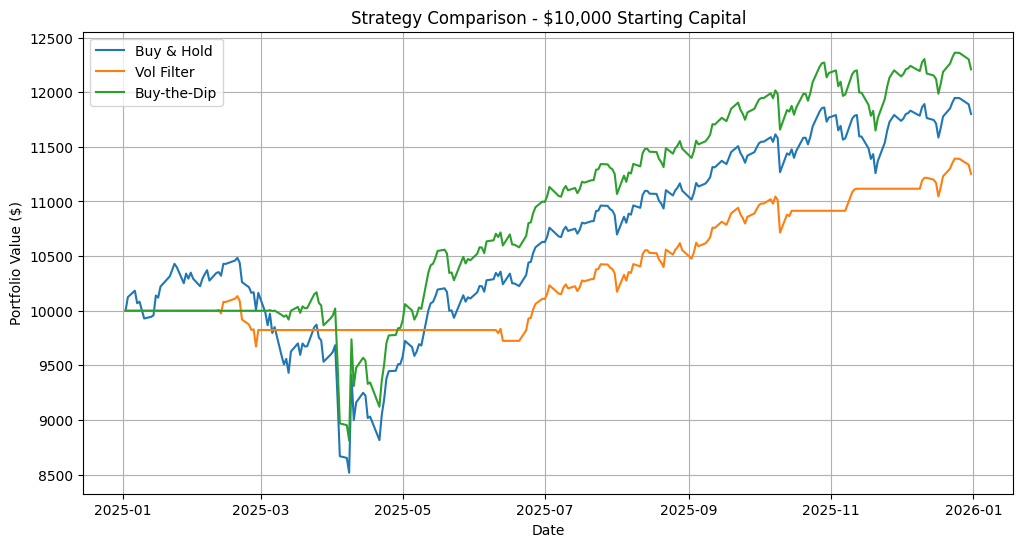

In [25]:
plt.figure(figsize=(12,6))
plt.plot(data['cumulative_buyhold']*10000, label='Buy & Hold')
plt.plot(data['cumulative_strategy']*10000, label='Vol Filter')
plt.plot(data['dip_strategy_value_capped'], label='Buy-the-Dip')
plt.title("Strategy Comparison - $10,000 Starting Capital")
plt.ylabel("Portfolio Value ($)")
plt.xlabel("Date")
plt.legend()
plt.grid(True)
plt.savefig('strategy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()